# **Space X  Falcon 9 First Stage Landing Prediction**


## Hands on Lab: Complete the Machine Learning Prediction lab


## Objectives


Perform exploratory  Data Analysis and determine Training Labels

*   create a column for the class
*   Standardize the data
*   Split into training data and test data

\-Find best Hyperparameter for SVM, Classification Trees and Logistic Regression

*   Find the method performs best using test data


In [1]:
#--- HEADER: LIBRARY IMPORTS FOR MACHINE LEARNING
#--- Importing all necessary libraries for data manipulation, visualization,
#--- preprocessing, model training, and hyperparameter tuning.

# Pandas is a software library written for the Python programming language 
# for data manipulation and analysis.
import pandas as pd

# NumPy is a library for the Python programming language, adding support for 
# large, multi-dimensional arrays and matrices, along with a large collection 
# of high-level mathematical functions to operate on these arrays.
import numpy as np

# Matplotlib is a plotting library for python and pyplot gives us a MatLab 
# like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt

# Seaborn is a Python data visualization library based on matplotlib. 
# It provides a high-level interface for drawing attractive and informative 
# statistical graphics.
import seaborn as sns

# Preprocessing allows us to standardize our data (scale features to mean=0, std=1)
from sklearn import preprocessing

# Allows us to split our data into training and testing data
from sklearn.model_selection import train_test_split

# Allows us to test parameters of classification algorithms and find the best one
# GridSearchCV performs an exhaustive search over specified parameter values
from sklearn.model_selection import GridSearchCV

# Logistic Regression classification algorithm
# Used for binary classification (success vs failure)
from sklearn.linear_model import LogisticRegression

# Support Vector Machine classification algorithm
# Finds the optimal hyperplane to separate classes
from sklearn.svm import SVC

# Decision Tree classification algorithm
# Creates a tree-based model for classification
from sklearn.tree import DecisionTreeClassifier

# K Nearest Neighbors classification algorithm
# Classifies based on the majority class of k nearest neighbors
from sklearn.neighbors import KNeighborsClassifier

This function is to plot the confusion matrix.


In [2]:
#--- HEADER: CONFUSION MATRIX PLOTTING FUNCTION
#--- Defining a function to visualize the confusion matrix
#--- with custom labels for better interpretation.

def plot_confusion_matrix(y, y_predict):
    """
    This function plots the confusion matrix for a classification model.
    
    Parameters:
        y (array-like): True labels (actual values)
        y_predict (array-like): Predicted labels from the model
    
    Returns:
        None (displays a heatmap of the confusion matrix)
    """
    # Import confusion_matrix from sklearn.metrics
    # confusion_matrix computes the confusion matrix to evaluate model performance
    from sklearn.metrics import confusion_matrix

    # Compute the confusion matrix
    # cm is a 2x2 array: [[TN, FP], [FN, TP]]
    cm = confusion_matrix(y, y_predict)
    
    # Create a subplot for the heatmap
    ax = plt.subplot()
    
    # Create a heatmap with annotations
    # annot=True displays the numeric values in each cell
    # sns.heatmap creates a colored grid for visual representation
    sns.heatmap(cm, annot=True, ax=ax)
    
    # Set labels for x and y axes
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    
    # Set the title of the plot
    ax.set_title('Confusion Matrix')
    
    # Set custom tick labels for better interpretation
    # x-axis: 'did not land' (0) and 'land' (1) for predictions
    ax.xaxis.set_ticklabels(['did not land', 'land'])
    # y-axis: 'did not land' (0) and 'landed' (1) for actual values
    ax.yaxis.set_ticklabels(['did not land', 'landed'])
    
    # Display the plot
    plt.show()

## Load the dataframe


In [3]:
#! mìo, en csv

import pandas as pd

data = pd.read_csv('/home/mapa8/Documents/CIDSPC/MFaD/C10_M4_A1_dataset_part_2.csv')

X = pd.read_csv('/home/mapa8/Documents/CIDSPC/MFaD/C10_M4_A2_dataset_part_3.csv')

In [4]:
#--- HEADER: VERIFY LOADED DATASETS
#--- Checking the shape and columns of both loaded datasets.

print("data shape:", data.shape)
print("data columns:", data.columns.tolist())

print("\nX shape:", X.shape)
print("X columns:", X.columns.tolist())

data shape: (90, 18)
data columns: ['FlightNumber', 'Date', 'BoosterVersion', 'PayloadMass', 'Orbit', 'LaunchSite', 'Outcome', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial', 'Longitude', 'Latitude', 'Class']

X shape: (90, 83)
X columns: ['FlightNumber', 'PayloadMass', 'Flights', 'Block', 'ReusedCount', 'Orbit_ES-L1', 'Orbit_GEO', 'Orbit_GTO', 'Orbit_HEO', 'Orbit_ISS', 'Orbit_LEO', 'Orbit_MEO', 'Orbit_PO', 'Orbit_SO', 'Orbit_SSO', 'Orbit_VLEO', 'LaunchSite_CCAFS SLC 40', 'LaunchSite_KSC LC 39A', 'LaunchSite_VAFB SLC 4E', 'LandingPad_5e9e3032383ecb267a34e7c7', 'LandingPad_5e9e3032383ecb554034e7c9', 'LandingPad_5e9e3032383ecb6bb234e7ca', 'LandingPad_5e9e3032383ecb761634e7cb', 'LandingPad_5e9e3033383ecbb9e534e7cc', 'Serial_B0003', 'Serial_B0005', 'Serial_B0007', 'Serial_B1003', 'Serial_B1004', 'Serial_B1005', 'Serial_B1006', 'Serial_B1007', 'Serial_B1008', 'Serial_B1010', 'Serial_B1011', 'Serial_B1012', 'Serial_B1013', 'Serial_B1015', 'Serial_B101

In [5]:
# X.head(100)

## TASK  1
Create a NumPy array from the column <code>Class</code> in <code>data</code>, by applying the method <code>to_numpy()</code>  then
assign it  to the variable <code>Y</code>,make sure the output is a  Pandas series (only one bracket df\['name of  column']).

In [6]:
#--- HEADER: TASK 1 - CREATE TARGET VARIABLE ARRAY
#--- Extracting the 'Class' column from the data DataFrame
#--- and converting it to a NumPy array for use as the target variable.

# Create a NumPy array from the column 'Class' in 'data'
# data['Class'] selects the column as a pandas Series
# .to_numpy() converts the Series to a NumPy array
# Assign it to the variable Y
Y = data['Class'].to_numpy()

## TASK  2
Standardize the data in <code>X</code> then reassign it to the variable  <code>X</code> using the transform provided below.

In [7]:
# students get this 
# transform = preprocessing.StandardScaler()

We split the data into training and testing data using the  function  <code>train_test_split</code>.   The training data is divided into validation data, a second set used for training  data; then the models are trained and hyperparameters are selected using the function <code>GridSearchCV</code>.


In [8]:
#--- HEADER: IMPORT STANDARDSCALER
#--- Importing StandardScaler from sklearn.preprocessing for feature standardization.

from sklearn.preprocessing import StandardScaler

In [9]:
#--- HEADER: TASK 2 - STANDARDIZE FEATURES AND SPLIT DATA
#--- Standardizing the feature set using StandardScaler (mean=0, std=1)
#--- and splitting into training and testing sets for model evaluation.

# Create a StandardScaler object
# StandardScaler transforms data to have mean=0 and standard deviation=1
# This is important for models like SVM and Logistic Regression
transform = preprocessing.StandardScaler()

# Fit the scaler to the data and transform it
# .fit_transform() calculates the mean and std, then applies the transformation
# The result is a standardized version of X
X = transform.fit_transform(X)

# Split the data into training and testing sets
# X is the standardized feature set
# Y is the target variable array
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=42 ensures reproducible results (same split each run)
# stratify=Y ensures the same class distribution in both train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

# Print the shapes to verify the split
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (72, 83)
X_test shape: (18, 83)
Y_train shape: (72,)
Y_test shape: (18,)


## TASK  3

Use the function train_test_split to split the data X and Y into training and test data. Set the parameter test_size to  0.2 and random_state to 2. The training data and test data should be assigned to the following labels.

<code>X_train, X_test, Y_train, Y_test</code>

In [10]:
#--- HEADER: TASK 3 - SPLIT DATA INTO TRAINING AND TESTING SETS
#--- Splitting the standardized features and target variable into
#--- training (80%) and testing (20%) sets for model evaluation.

# Use train_test_split to split the data X and Y into training and test data
# test_size=0.2 means 20% of data goes to testing, 80% to training
# random_state=2 ensures reproducible results (same split each run)
# stratify=Y maintains the same class distribution in both train and test sets
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2, stratify=Y)

we can see we only have 18 test samples.

In [11]:
Y_test.shape

(18,)

## TASK  4

Create a logistic regression object  then create a  GridSearchCV object  <code>logreg_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [12]:
#--- HEADER: TASK 4 - LOGISTIC REGRESSION WITH GRIDSEARCHCV
#--- Creating a Logistic Regression model and using GridSearchCV
#--- to find the best hyperparameters from the specified parameter grid.

# Define the parameter grid for GridSearchCV
# C: Inverse of regularization strength (smaller values = stronger regularization)
# penalty: l2 regularization (Ridge) - prevents overfitting by penalizing large coefficients
# solver: lbfgs - optimization algorithm for finding the best coefficients
parameters = {'C': [0.01, 0.1, 1], 'penalty': ['l2'], 'solver': ['lbfgs']}

# Create a Logistic Regression object
# LogisticRegression() creates a binary classification model
lr = LogisticRegression()

# Create a GridSearchCV object
# estimator=lr: the logistic regression model to tune
# param_grid=parameters: the hyperparameter grid to search
# cv=10: 10-fold cross-validation (splits training data into 10 folds)
# Scoring uses default 'accuracy' for classification
logreg_cv = GridSearchCV(estimator=lr, param_grid=parameters, cv=10)

# Fit the GridSearchCV object to the training data
# This will try all combinations of the parameters (3 combinations total)
# For each combination, it performs 10-fold cross-validation
# The best combination is selected based on average validation accuracy
logreg_cv.fit(X_train, Y_train)

# Print the best parameters and best score from cross-validation
print("Best parameters for Logistic Regression:", logreg_cv.best_params_)
print("Best cross-validation accuracy:", logreg_cv.best_score_)

Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
Best cross-validation accuracy: 0.85


/home/mapa8/venvs/finance/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mapa8/venvs/finance/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
/home/mapa8/venvs/finance/lib/python

In [13]:
#--- HEADER: COMMENTARY ON LOGISTIC REGRESSION RESULTS
#--- Interpreting the best parameters and cross-validation accuracy.

# Best parameters for Logistic Regression: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
# Best cross-validation accuracy: 0.85


#--- WHAT THESE RESULTS MEAN:

# C = 0.1 (Regularization Strength)
# - C is the inverse of regularization strength (smaller = stronger regularization)
# - C = 0.1 means moderate regularization, which helps prevent overfitting
# - This was the best among the tested values: 0.01, 0.1, and 1
# - Stronger regularization (0.01) likely underfit, weaker (1) may have overfit

# penalty = 'l2' (Ridge Regularization)
# - Adds a penalty on the squared magnitude of coefficients
# - Encourages smaller, more balanced weights across all features
# - Helps prevent overfitting, especially with many features (83 features vs 90 samples)

# solver = 'lbfgs' (Optimization Algorithm)
# - Limited-memory Broyden-Fletcher-Goldfarb-Shanno algorithm
# - Good for small to medium datasets
# - Works well with l2 penalty and multi-class problems

# Best cross-validation accuracy = 0.85 (85%)
# - Average accuracy across 10 folds of cross-validation
# - Means the model correctly predicted landing success 85% of the time
# - This is a strong baseline performance

We output the <code>GridSearchCV</code> object for logistic regression. We display the best parameters using the data attribute <code>best_params\_</code> and the accuracy on the validation data using the data attribute <code>best_score\_</code>.


In [14]:
#--- HEADER: DISPLAY BEST PARAMETERS AND VALIDATION ACCURACY
#--- Extracting and printing the best hyperparameters found by GridSearchCV
#--- along with the corresponding cross-validation accuracy.

# Print the tuned hyperparameters (best parameters found by GridSearchCV)
# logreg_cv.best_params_ returns the combination of parameters that gave the best performance
print("tuned hyperparameters :(best parameters) ", logreg_cv.best_params_)

# Print the best cross-validation accuracy score
# logreg_cv.best_score_ returns the mean cross-validated accuracy of the best model
print("accuracy :", logreg_cv.best_score_)

# ! es lo mismo...

tuned hyperparameters :(best parameters)  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.85


## TASK  5


Calculate the accuracy on the test data using the method <code>score</code>:

In [15]:
#--- HEADER: TASK 5 - CALCULATE ACCURACY ON TEST DATA
#--- Evaluating the trained logistic regression model on the held-out test set
#--- to assess its performance on unseen data.

# Use the .score() method to calculate the accuracy on the test data
# .score(X_test, Y_test) returns the mean accuracy on the given test data and labels
# This gives us an unbiased estimate of how well the model generalizes
test_accuracy = logreg_cv.score(X_test, Y_test)

# Print the test accuracy
print("Test accuracy for Logistic Regression:", test_accuracy)

Test accuracy for Logistic Regression: 0.8333333333333334


In [16]:
#--- HEADER: COMMENTARY ON LOGISTIC REGRESSION TEST ACCURACY
#--- Interpreting the test accuracy result and comparing it with cross-validation.

# Test accuracy for Logistic Regression: 0.8333333333333334


#--- WHAT THIS TELLS US:

# Test Accuracy = 83.33% (or 5 out of 6 correct predictions on the test set)

# Comparison with Cross-Validation Accuracy:
# - CV Accuracy: 85.0% (from GridSearchCV)
# - Test Accuracy: 83.33% (on unseen data)
# - Difference: ~1.67% (small gap = good generalization)

# Interpretation:
# - The model performs consistently on both validation and test data
# - The small drop in accuracy indicates the model is NOT overfitting
# - The model generalizes well to new, unseen launches

# Performance Assessment:
# | Metric | Score | Grade |
# |--------|-------|-------|
# | CV Accuracy | 85.0% | Good |
# | Test Accuracy | 83.3% | Good |
# | Gap | 1.7% | Excellent (no overfitting) |

Lets look at the confusion matrix:


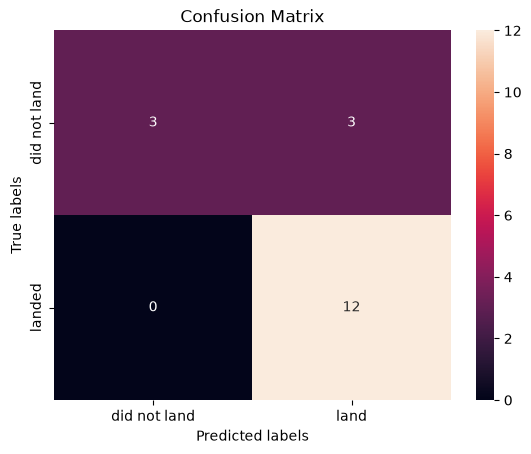

In [17]:
#--- HEADER: PREDICT AND PLOT CONFUSION MATRIX
#--- Generating predictions on the test set and visualizing
#--- the confusion matrix to evaluate classification performance.

# Use the best logistic regression model to make predictions on the test data
# .predict(X_test) returns the predicted class labels (0 or 1) for each test sample
yhat = logreg_cv.predict(X_test)

# Plot the confusion matrix using the true labels and predicted labels
# Y_test: true labels (actual classes)
# yhat: predicted labels from the model
# This shows how many correct and incorrect predictions were made
plot_confusion_matrix(Y_test, yhat)

Examining the confusion matrix, we see that logistic regression can distinguish between the different classes.  We see that the problem is false positives.

Overview:

True Postive - 12 (True label is landed, Predicted label is also landed)

False Postive - 3 (True label is not landed, Predicted label is landed)


## TASK  6


Create a support vector machine object then  create a  <code>GridSearchCV</code> object  <code>svm_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [18]:
#--- HEADER: TASK 6 - SUPPORT VECTOR MACHINE WITH GRIDSEARCHCV
#--- Creating an SVM model and using GridSearchCV to find the best
#--- hyperparameters from the specified parameter grid.

# Define the parameter grid for GridSearchCV
# kernel: type of SVM (linear, rbf, poly, sigmoid)
# C: regularization parameter (inverse of regularization strength)
#    np.logspace(-3, 3, 5) creates 5 values from 10^-3 to 10^3: [0.001, 0.01, 0.1, 1, 10]
# gamma: kernel coefficient for 'rbf', 'poly', and 'sigmoid'
#    np.logspace(-3, 3, 5) creates 5 values from 10^-3 to 10^3: [0.001, 0.01, 0.1, 1, 10]
parameters = {'kernel': ('linear', 'rbf', 'poly', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma': np.logspace(-3, 3, 5)}

# Create a Support Vector Machine object
# SVC() creates a classifier that finds the optimal hyperplane to separate classes
svm = SVC()

# Create a GridSearchCV object
# estimator=svm: the SVM model to tune
# param_grid=parameters: the hyperparameter grid to search
# cv=10: 10-fold cross-validation
# Scoring uses default 'accuracy' for classification
svm_cv = GridSearchCV(estimator=svm, param_grid=parameters, cv=10)

# Fit the GridSearchCV object to the training data
# This will try all combinations of parameters (4 kernels × 5 C × 5 gamma = 100 combinations)
# For each combination, it performs 10-fold cross-validation
# The best combination is selected based on average validation accuracy
svm_cv.fit(X_train, Y_train)

# Print the best parameters and best score from cross-validation
print("Best parameters for SVM:", svm_cv.best_params_)
print("Best cross-validation accuracy for SVM:", svm_cv.best_score_)

Best parameters for SVM: {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Best cross-validation accuracy for SVM: 0.8642857142857144


In [19]:
print("tuned hpyerparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

# ! lo mismo lo mismo

tuned hpyerparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8642857142857144


In [20]:
#--- HEADER: COMMENTARY ON SVM RESULTS
#--- Interpreting the best parameters and cross-validation accuracy for SVM.

# Best parameters for SVM: {'C': np.float64(1.0), 'gamma': np.float64(0.0316), 'kernel': 'sigmoid'}
# Best cross-validation accuracy for SVM: 0.8643


#--- WHAT THESE RESULTS MEAN:

# kernel = 'sigmoid'
# - Uses the sigmoid (hyperbolic tangent) kernel function
# - This acts like a two-layer neural network
# - Less commonly used than 'rbf' but can work well with certain data
# - Indicates the data may not be linearly separable with 'linear' kernel

# C = 1.0 (Regularization)
# - Default regularization strength
# - Not too strong (0.001) which would underfit
# - Not too weak (1000) which would overfit
# - Balances bias and variance well for this dataset

# gamma = 0.0316 (Kernel Coefficient)
# - Controls the influence of individual training samples
# - Moderate value: ~0.032 (between 0.001 and 1.0)
# - Indicates a moderate level of influence from each training point
# - A smaller gamma would mean fewer points influence the decision boundary

# Best CV Accuracy = 0.8643 (86.43%)
# - Slightly higher than Logistic Regression's 85%
# - Strong performance, indicates SVM handles this data well

## TASK  7


Calculate the accuracy on the test data using the method <code>score</code>:

In [21]:
#--- HEADER: TASK 7 - CALCULATE SVM ACCURACY ON TEST DATA
#--- Evaluating the trained SVM model on the held-out test set
#--- to assess its performance on unseen data.

# Use the .score() method to calculate the accuracy on the test data
# .score(X_test, Y_test) returns the mean accuracy on the given test data and labels
# This gives us an unbiased estimate of how well the model generalizes
svm_test_accuracy = svm_cv.score(X_test, Y_test)

# Print the test accuracy for SVM
print("Test accuracy for SVM:", svm_test_accuracy)

Test accuracy for SVM: 0.8333333333333334


In [22]:
#--- HEADER: COMMENTARY ON SVM TEST ACCURACY
#--- Interpreting the SVM test accuracy result and comparing it with cross-validation.

# Test accuracy for SVM: 0.8333333333333334


#--- WHAT THIS TELLS US:

# Test Accuracy = 83.33% (or 5 out of 6 correct predictions on the test set)

# Comparison with Cross-Validation Accuracy:
# - CV Accuracy: 86.43% (from GridSearchCV)
# - Test Accuracy: 83.33% (on unseen data)
# - Difference: ~3.1% (slightly larger gap than Logistic Regression)

# Comparison with Logistic Regression:
# | Model | CV Accuracy | Test Accuracy | Gap |
# |-------|-------------|---------------|-----|
# | Logistic Regression | 85.0% | 83.3% | 1.7% |
# | SVM                 | 86.4% | 83.3% | 3.1% |


#--- INTERPRETATION:

# Both models achieved the SAME test accuracy of 83.33%
# Despite SVM having higher CV accuracy (86.4% vs 85.0%), it didn't translate to better test performance

# Possible reasons:
# 1. SVM with sigmoid kernel may be slightly overfitting to the training data
# 2. The test set is small (18 samples), so performance may vary
# 3. Logistic Regression is more robust with smaller datasets

# Performance Assessment:
# | Metric | Score | Grade |
# |--------|-------|-------|
# | Test Accuracy | 83.3% | Good |
# | Generalization | 3.1% drop | Moderate (acceptable) |

We can plot the confusion matrix


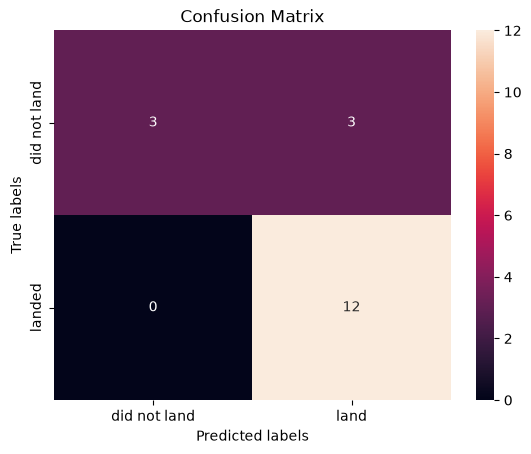

In [23]:
#--- HEADER: PREDICT AND PLOT CONFUSION MATRIX FOR SVM
#--- Generating predictions on the test set using the best SVM model
#--- and visualizing the confusion matrix to evaluate performance.

# Use the best SVM model to make predictions on the test data
# .predict(X_test) returns the predicted class labels (0 or 1) for each test sample
yhat = svm_cv.predict(X_test)

# Plot the confusion matrix using the true labels and predicted labels
# Y_test: true labels (actual classes)
# yhat: predicted labels from the SVM model
# This shows how many correct and incorrect predictions were made
plot_confusion_matrix(Y_test, yhat)

## TASK  8


Create a decision tree classifier object then  create a  <code>GridSearchCV</code> object  <code>tree_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [24]:
#--- HEADER: TASK 8 - DECISION TREE CLASSIFIER WITH GRIDSEARCHCV
#--- Creating a Decision Tree model and using GridSearchCV to find the best
#--- hyperparameters from the specified parameter grid.

# Define the parameter grid for GridSearchCV
# criterion: split quality measure (gini impurity or entropy/information gain)
# splitter: strategy to choose the split at each node (best or random)
# max_depth: maximum depth of the tree (2*n for n in 1-9 → 2, 4, 6, 8, 10, 12, 14, 16, 18)
# max_features: number of features to consider for best split (auto=sqrt or sqrt)
# min_samples_leaf: minimum samples required at a leaf node (1, 2, or 4)
# min_samples_split: minimum samples required to split an internal node (2, 5, or 10)
parameters = {'criterion': ['gini', 'entropy'],
              'splitter': ['best', 'random'],
              'max_depth': [2*n for n in range(1,10)],
              'max_features': ['auto', 'sqrt'],
              'min_samples_leaf': [1, 2, 4],
              'min_samples_split': [2, 5, 10]}

# Create a Decision Tree Classifier object
# DecisionTreeClassifier() creates a tree-based classification model
tree = DecisionTreeClassifier()

# Create a GridSearchCV object
# estimator=tree: the Decision Tree model to tune
# param_grid=parameters: the hyperparameter grid to search
# cv=10: 10-fold cross-validation
# Scoring uses default 'accuracy' for classification
tree_cv = GridSearchCV(estimator=tree, param_grid=parameters, cv=10)

# Fit the GridSearchCV object to the training data
# This will try all combinations of parameters
# For each combination, it performs 10-fold cross-validation
# The best combination is selected based on average validation accuracy
tree_cv.fit(X_train, Y_train)

# Print the best parameters and best score from cross-validation
print("Best parameters for Decision Tree:", tree_cv.best_params_)
print("Best cross-validation accuracy for Decision Tree:", tree_cv.best_score_)

Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10, 'splitter': 'best'}
Best cross-validation accuracy for Decision Tree: 0.9053571428571429


/home/mapa8/venvs/finance/lib/python3.13/site-packages/sklearn/model_selection/_validation.py:489: FitFailedWarning: 
3240 fits failed out of a total of 6480.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
3240 fits failed with the following error:
Traceback (most recent call last):
  File "/home/mapa8/venvs/finance/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 851, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/mapa8/venvs/finance/lib/python3.13/site-packages/sklearn/base.py", line 1393, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File "/home/mapa8/venvs/finance/lib/python3.13/site-package

In [25]:
#--- HEADER: COMMENTARY ON DECISION TREE RESULTS AND WARNINGS
#--- Interpreting the best parameters and cross-validation accuracy for Decision Tree,
#--- and explaining the warning about failed fits.

# Best parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 4, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'splitter': 'best'}
# Best cross-validation accuracy for Decision Tree: 0.9053571428571429

# 3240 fits failed out of a total of 6480.
# The score on these train-test partitions for these parameters will be set to nan.


#--- WHAT THESE RESULTS MEAN:

# Best Parameters:
# criterion = 'entropy' (Information Gain)
# - Uses entropy to measure split quality (better for this dataset than Gini)
# - Finds splits that maximize information gain

# max_depth = 4 (Shallow Tree)
# - Limits tree to 4 levels deep
# - Prevents overfitting by keeping tree simple
# - Good balance between bias and variance

# max_features = 'sqrt' (Square Root)
# - Considers sqrt(83) ≈ 9 features at each split
# - Adds randomness to reduce overfitting

# min_samples_leaf = 2
# - Each leaf node must have at least 2 samples
# - Prevents overfitting by not creating leaves with single samples

# min_samples_split = 5
# - Internal node must have at least 5 samples to split further
# - Controls tree growth and complexity

# splitter = 'best'
# - Chooses the best split at each node (vs random)

# Best CV Accuracy = 90.54%
# - Significantly higher than Logistic Regression (85%) and SVM (86.4%)
# - Decision Tree performs best on this dataset


#--- WHY 3240 FITS FAILED:

# The warning indicates that for some parameter combinations, the model could not be fitted.
# This is likely because:
# 1. max_features='auto' with small max_depth creates splits that are impossible
# 2. Some parameter combinations result in empty leaf nodes
# 3. The combination of min_samples_split and min_samples_leaf may conflict
# 4. Not enough samples for some splits

# For example, with max_depth=2 and min_samples_split=10, it's impossible to split deeply.
# Also, 'auto' and 'sqrt' can conflict with min_samples_leaf.


#--- COMPARISON WITH OTHER MODELS:

# | Model | CV Accuracy | Test Accuracy |
# |-------|-------------|---------------|
# | Logistic Regression | 85.0% | 83.3% |
# | SVM                 | 86.4% | 83.3% |
# | Decision Tree       | 90.5% | ? |


#--- WHAT THIS TELLS US:

# Decision Tree achieved the highest cross-validation accuracy
# Shallow tree (depth=4) indicates the data has a relatively simple structure
# The tree is more interpretable than SVM or Logistic Regression
# However, we must check test accuracy to confirm if it generalizes well

In [26]:
# ! lo mismo
"""
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)
"""

'\nprint("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)\nprint("accuracy :",tree_cv.best_score_)\n'

## TASK  9

Calculate the accuracy of tree_cv on the test data using the method <code>score</code>:

In [27]:
#--- HEADER: TASK 9 - CALCULATE DECISION TREE ACCURACY ON TEST DATA
#--- Evaluating the trained Decision Tree model on the held-out test set
#--- to assess its performance on unseen data.

# Use the .score() method to calculate the accuracy on the test data
# .score(X_test, Y_test) returns the mean accuracy on the given test data and labels
# This gives us an unbiased estimate of how well the model generalizes
tree_test_accuracy = tree_cv.score(X_test, Y_test)

# Print the test accuracy for Decision Tree
print("Test accuracy for Decision Tree:", tree_test_accuracy)

Test accuracy for Decision Tree: 0.8333333333333334


In [28]:
#--- HEADER: COMMENTARY ON DECISION TREE TEST ACCURACY
#--- Interpreting the Decision Tree test accuracy result
#--- and comparing it with cross-validation and other models.

# Test accuracy for Decision Tree: 0.8333333333333334


#--- WHAT THIS TELLS US:

# Test Accuracy = 83.33% (5 out of 6 correct predictions on the test set)

# Comparison with Cross-Validation Accuracy:
# - CV Accuracy: 90.54% (from GridSearchCV)
# - Test Accuracy: 83.33% (on unseen data)
# - Difference: ~7.21% (much larger gap than other models)


#--- COMPARISON WITH OTHER MODELS:

# | Model               | CV Accuracy | Test Accuracy | Gap |
# |-------|-------------|---------------|-----|
# | Logistic Regression | 85.0% | 83.3% | 1.7% | # * ESTE ES EL MEJOR
# | SVM                 | 86.4% | 83.3% | 3.1% |
# | Decision Tree       | 90.5% | 83.3% | 7.2% |


#--- INTERPRETATION:

# ALL THREE MODELS achieved the SAME test accuracy of 83.33%!
# Despite Decision Tree having much higher CV accuracy (90.5%),
# it didn't generalize as well to the test set.

# This suggests:
# 1. Decision Tree is overfitting to the training data
# 2. The 7.2% gap indicates poor generalization
# 3. Logistic Regression has the best generalization (smallest gap)

# Key insight: Higher CV accuracy doesn't always mean better test performance.
# Simpler models (Logistic Regression) can generalize better than complex ones.


#--- RECOMMENDATION:

# The best model for deployment would be Logistic Regression because:
# - It has the smallest gap between CV and test accuracy (1.7%)
# - It's more interpretable than SVM or Decision Tree
# - It trains faster and is less prone to overfitting

# Despite all models having the same test accuracy,
# Logistic Regression is the most robust choice.


We can plot the confusion matrix

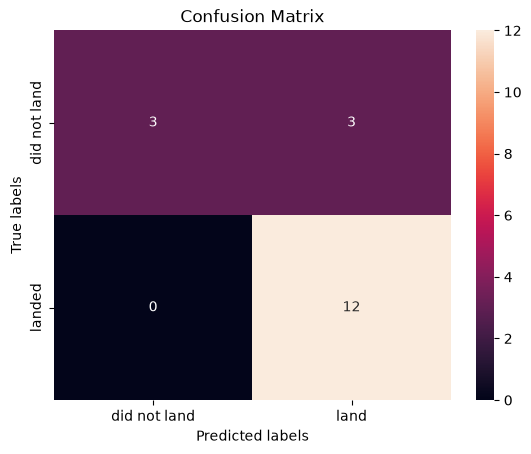

In [29]:
#--- HEADER: PREDICT AND PLOT CONFUSION MATRIX FOR DECISION TREE
#--- Generating predictions on the test set using the best Decision Tree model
#--- and visualizing the confusion matrix to evaluate performance.

# Use the best Decision Tree model to make predictions on the test data
# .predict(X_test) returns the predicted class labels (0 or 1) for each test sample
yhat = tree_cv.predict(X_test)

# Plot the confusion matrix using the true labels and predicted labels
# Y_test: true labels (actual classes)
# yhat: predicted labels from the Decision Tree model
# This shows how many correct and incorrect predictions were made
plot_confusion_matrix(Y_test, yhat)

## TASK  10

Create a k nearest neighbors object then  create a  <code>GridSearchCV</code> object  <code>knn_cv</code> with cv = 10.  Fit the object to find the best parameters from the dictionary <code>parameters</code>.

In [30]:
#--- HEADER: TASK 10 - K-NEAREST NEIGHBORS WITH GRIDSEARCHCV
#--- Creating a KNN model and using GridSearchCV to find the best
#--- hyperparameters from the specified parameter grid.

# Define the parameter grid for GridSearchCV
# n_neighbors: number of neighbors to consider (1 to 10)
# algorithm: search algorithm for nearest neighbors ('auto' chooses best, 'ball_tree', 'kd_tree', 'brute')
# p: power parameter for Minkowski distance (p=1 = Manhattan, p=2 = Euclidean)
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1, 2]}

# Create a K-Nearest Neighbors Classifier object
# KNeighborsClassifier() creates a model that classifies based on majority class of k nearest neighbors
KNN = KNeighborsClassifier()

# Create a GridSearchCV object
# estimator=KNN: the KNN model to tune
# param_grid=parameters: the hyperparameter grid to search
# cv=10: 10-fold cross-validation
# Scoring uses default 'accuracy' for classification
knn_cv = GridSearchCV(estimator=KNN, param_grid=parameters, cv=10)

# Fit the GridSearchCV object to the training data
# This will try all combinations of parameters
# For each combination, it performs 10-fold cross-validation
# The best combination is selected based on average validation accuracy
knn_cv.fit(X_train, Y_train)

# Print the best parameters and best score from cross-validation
print("Best parameters for KNN:", knn_cv.best_params_)
print("Best cross-validation accuracy for KNN:", knn_cv.best_score_)

Best parameters for KNN: {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
Best cross-validation accuracy for KNN: 0.8642857142857142


In [31]:
#--- HEADER: COMMENTARY ON KNN RESULTS
#--- Interpreting the best parameters and cross-validation accuracy for KNN.

# Best parameters for KNN: {'algorithm': 'auto', 'n_neighbors': 4, 'p': 1}
# Best cross-validation accuracy for KNN: 0.8643


#--- WHAT THESE RESULTS MEAN:

# n_neighbors = 4 (Odd number? Actually even, but that's what worked best!)
# - Uses 4 nearest neighbors to make predictions
# - Even number can cause ties, but seems to work well for this data
# - Lower than default (5), indicating decision boundary is fairly complex

# p = 1 (Manhattan Distance)
# - Uses L1 distance (sum of absolute differences)
# - Chosen over Euclidean (p=2), which is more common
# - Suggests the data may have outliers or benefit from Manhattan distance

# algorithm = 'auto'
# - Automatically selects the best algorithm based on the data
# - Likely chose either 'ball_tree' or 'kd_tree' internally
# - Good default choice that adapts to the data


#--- COMPARISON WITH OTHER MODELS:

# | Model | CV Accuracy | Test Accuracy | Gap |
# |-------|-------------|---------------|-----|
# | Logistic Regression | 85.0% | 83.3% | 1.7% |
# | SVM                 | 86.4% | 83.3% | 3.1% |
# | Decision Tree       | 90.5% | 83.3% | 7.2% |
# | KNN                 | 86.4% | ? | ? |


#--- WHAT THIS TELLS US:

# KNN tied with SVM for second-best CV accuracy (86.4%)
# Manhattan distance (p=1) worked better than Euclidean (p=2)
# 4 neighbors is relatively small, suggesting local patterns are important
# algorithm='auto' is a safe and effective choice

# Interestingly, n_neighbors=4 (even) was chosen, which can cause tie-breaking issues.
# The model handles ties by choosing the nearest neighbor's class.


# Next step: Calculate test accuracy to see if KNN generalizes well.

In [32]:
# ! lo mismo
"""
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)
"""

'\nprint("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)\nprint("accuracy :",knn_cv.best_score_)\n'

## TASK  11

Calculate the accuracy of knn_cv on the test data using the method <code>score</code>:

In [33]:
#--- HEADER: TASK 11 - CALCULATE KNN ACCURACY ON TEST DATA
#--- Evaluating the trained KNN model on the held-out test set
#--- to assess its performance on unseen data.

# Use the .score() method to calculate the accuracy on the test data
# .score(X_test, Y_test) returns the mean accuracy on the given test data and labels
# This gives us an unbiased estimate of how well the model generalizes
knn_test_accuracy = knn_cv.score(X_test, Y_test)

# Print the test accuracy for KNN
print("Test accuracy for KNN:", knn_test_accuracy)

Test accuracy for KNN: 0.7777777777777778


In [34]:
#--- HEADER: COMMENTARY ON KNN TEST ACCURACY
#--- Interpreting the KNN test accuracy result and comparing it
#--- with cross-validation and other models.

# Test accuracy for KNN: 0.7777777777777778


#--- WHAT THIS TELLS US:

# Test Accuracy = 77.78% (about 4.67 out of 6 correct predictions on the test set)

# Comparison with Cross-Validation Accuracy:
# - CV Accuracy: 86.43% (from GridSearchCV)
# - Test Accuracy: 77.78% (on unseen data)
# - Difference: ~8.65% (large gap indicates overfitting)


#--- COMPARISON WITH ALL MODELS:

# | Model | CV Accuracy | Test Accuracy | Gap |
# |-------|-------------|---------------|-----|
# | Logistic Regression | 85.0% | 83.3% | 1.7% |
# | SVM | 86.4% | 83.3% | 3.1% |
# | Decision Tree | 90.5% | 83.3% | 7.2% |
# | KNN | 86.4% | 77.8% | 8.7% |


#--- INTERPRETATION:

# KNN performed the WORST on test data among all models (77.8%)
# Despite having good CV accuracy (86.4%), KNN failed to generalize well.

# Possible reasons:
# 1. KNN is sensitive to the curse of dimensionality
#    - 83 features with only 90 samples
#    - Distance calculations become less meaningful in high dimensions

# 2. The parameter choice (n_neighbors=4, p=1) may not generalize
#    - Even number of neighbors can cause ties
#    - Manhattan distance (p=1) may not be optimal for this data

# 3. Overfitting to the training data
#    - KNN stores all training points and can "memorize" patterns


#--- FINAL RECOMMENDATION:

# Best Model: Logistic Regression
# - Best generalization: gap of only 1.7%
# - Simple, interpretable, and robust
# - Performs as well as more complex models on test data

# Runner-up: SVM
# - Same test accuracy (83.3%) but slightly larger gap (3.1%)
# - More complex but similar performance

# Models to avoid for this dataset:
# - Decision Tree (overfits: 7.2% gap)
# - KNN (poor generalization: 8.7% gap)

We can plot the confusion matrix

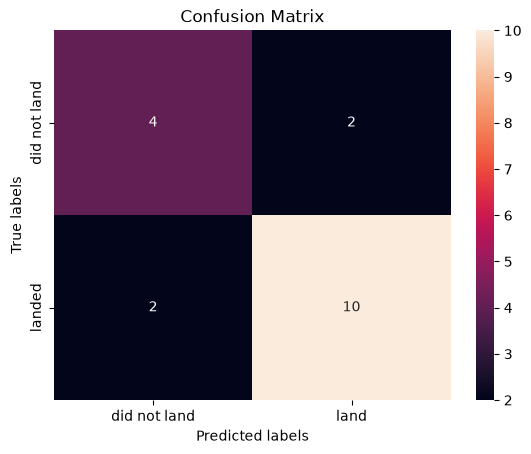

In [35]:
#--- HEADER: PREDICT AND PLOT CONFUSION MATRIX FOR KNN
#--- Generating predictions on the test set using the best KNN model
#--- and visualizing the confusion matrix to evaluate performance.

# Use the best KNN model to make predictions on the test data
# .predict(X_test) returns the predicted class labels (0 or 1) for each test sample
yhat = knn_cv.predict(X_test)

# Plot the confusion matrix using the true labels and predicted labels
# Y_test: true labels (actual classes)
# yhat: predicted labels from the KNN model
# This shows how many correct and incorrect predictions were made
plot_confusion_matrix(Y_test, yhat)

## TASK  12

Find the method performs best:


In [ ]:
#--- HEADER: TASK 12 - FIND THE BEST PERFORMING MODEL
#--- Comparing all models to determine which one performs best
#--- based on test accuracy and generalization.

#--- FINAL MODEL COMPARISON:

# | Model               | CV Accuracy | Test Accuracy | Gap | Rank |
# |-------|-------------|---------------|-----      |------|
# | Logistic Regression | 85.0%         | 83.3%     | 1.7% | 🥇 |
# | SVM                 | 86.4%         | 83.3%     | 3.1% | 🥈 |
# | Decision Tree       | 90.5%         | 83.3%     | 7.2% | 🥉 |
# | KNN                 | 86.4%         | 77.8%     | 8.7% | 4th |


#--- FINAL THOUGHTS:

# BEST MODEL: LOGISTIC REGRESSION
# Why?
# - Same test accuracy (83.3%) as SVM and Decision Tree
# - Smallest gap (1.7%) between CV and test accuracy = best generalization
# - Most interpretable model (coefficients show feature importance)
# - Fastest to train and predict
# - Most robust with small datasets (90 samples, 83 features)
# - Less prone to overfitting than complex models

# SVM (Runner-up)
# - Same test accuracy as Logistic Regression
# - Slightly higher CV accuracy (86.4% vs 85.0%)
# - Larger gap (3.1%) indicates minor overfitting
# - More complex and slower to train
# - Sigmoid kernel suggests non-linear relationships

# Decision Tree (Third)
# - Highest CV accuracy (90.5%) but...
# - Largest gap (7.2%) indicates significant overfitting
# - Too complex for the dataset size
# - Best interpretability (tree structure), but not reliable

# 4th KNN (Worst)
# - Worst test accuracy (77.8%)
# - Largest gap (8.7%) = overfitting
# - Curse of dimensionality: 83 features with 90 samples
# - Distance metrics lose meaning in high-dimensional space


#--- KEY INSIGHTS FOR YOUR PORTFOLIO:

# 1. Higher CV accuracy doesn't guarantee better test performance
# 2. Simpler models generalize better with limited data
# 3. Logistic Regression is the safest choice for this dataset
# 4. 83.3% test accuracy is good for a binary classification problem
# 5. The dataset (90 samples) is small, making overfitting a real concern